# Greenfilling trade-offs

A first, exploratory look at the small stress campaign. The goal is to get a feel for what greenfilling (optimizing either carbon or water) does to the environmental footprint and to job performance, compared to plain EASY backfilling on the same workload and the same environmental window.

It is a stress workload, so the machine stays busy and there is not much room in the schedule to play with. I would expect any environmental effect to be small here.

This analysis look at replay jobs separately before saying anything about performance.

## Load Campaign Metadata

In [16]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tomllib


pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})


root = Path.cwd()
if not (root / "experiments").exists():
    root = root.parent

campaign_path = root / "experiments" / "experiments_small.toml"
windows_path = root / "intensities" / "traces" / "small" / "windows.csv"
out_dir = root / "experiments" / "out"

print(f"root: {root}")
print(f"campaign: {campaign_path}")
print(f"windows: {windows_path}")
print(f"outputs: {out_dir}")

root: /Users/lucas/ws/doct/experimental-artifacts
campaign: /Users/lucas/ws/doct/experimental-artifacts/experiments/experiments_small.toml
windows: /Users/lucas/ws/doct/experimental-artifacts/intensities/traces/small/windows.csv
outputs: /Users/lucas/ws/doct/experimental-artifacts/experiments/out


In [17]:
def parse_experiment_name(name):
    baseline = re.fullmatch(r"(fcfs|easy_bf)_([^_]+)_([A-Z]{2})_(\d{4}-\d{2}-\d{2})", name)
    if baseline:
        variant, workload, zone, start_date = baseline.groups()
        return {
            "variant": variant,
            "objective": "baseline",
            "workload_label": workload,
            "zone": zone,
            "start_date": start_date,
        }

    greenfilling = re.fullmatch(
        r"greenfilling_(carbon|water)_([^_]+)_([A-Z]{2})_(\d{4}-\d{2}-\d{2})",
        name,
    )
    if greenfilling:
        objective, workload, zone, start_date = greenfilling.groups()
        return {
            "variant": f"greenfilling_{objective}",
            "objective": objective,
            "workload_label": workload,
            "zone": zone,
            "start_date": start_date,
        }

    raise ValueError(f"Unexpected experiment name: {name}")


with campaign_path.open("rb") as file:
    campaign = pd.DataFrame(tomllib.load(file)["experiment"])

name_parts = pd.DataFrame([parse_experiment_name(name) for name in campaign["name"]])
campaign = pd.concat([campaign, name_parts], axis=1)

# Keep EASY as the baseline alongside the greenfilling variants.
campaign = campaign[campaign["variant"].ne("fcfs")].reset_index(drop=True)

windows = pd.read_csv(windows_path)

display(campaign.head())
display(windows.head())

,name,workload,platform,environmental_trace,variant_name,variant_options,variant,objective,workload_label,zone,start_date
0,easy_bf_stress_DE_2019-02-04,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2019-02-04.csv,easy_bf,,easy_bf,baseline,stress,DE,2019-02-04
1,easy_bf_stress_DE_2019-04-22,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2019-04-22.csv,easy_bf,,easy_bf,baseline,stress,DE,2019-04-22
2,easy_bf_stress_DE_2022-06-27,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2022-06-27.csv,easy_bf,,easy_bf,baseline,stress,DE,2022-06-27
3,easy_bf_stress_DE_2023-05-15,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2023-05-15.csv,easy_bf,,easy_bf,baseline,stress,DE,2023-05-15
4,easy_bf_stress_DE_2024-01-01,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2024-01-01.csv,easy_bf,,easy_bf,baseline,stress,DE,2024-01-01


,zone,file,start_date,season,year,mean_carbon,mean_water,swing_carbon,swing_water
0,DE,traces/small/DE_2019-02-04.csv,2019-02-04,winter,2019,287.1696,1.2927,0.3065,0.2646
1,DE,traces/small/DE_2019-04-22.csv,2019-04-22,spring,2019,266.2537,1.5290,0.4340,0.4289
2,DE,traces/small/DE_2022-06-27.csv,2022-06-27,summer,2022,387.8807,1.6624,0.5225,0.5640
3,DE,traces/small/DE_2023-05-15.csv,2023-05-15,spring,2023,254.2366,1.4861,0.7373,0.7356
4,DE,traces/small/DE_2024-01-01.csv,2024-01-01,winter,2024,255.2737,1.2785,0.4000,0.4007


## Check Result Completeness

In [18]:
result_files = []
for row in campaign.itertuples(index=False):
    experiment_dir = out_dir / row.name
    result_files.append(
        {
            "name": row.name,
            "variant": row.variant,
            "zone": row.zone,
            "start_date": row.start_date,
            "has_directory": experiment_dir.exists(),
            "has_schedule": (experiment_dir / "out_schedule.csv").exists(),
            "has_jobs": (experiment_dir / "out_jobs.csv").exists(),
            "has_environmental_footprint": (experiment_dir / "out_environmental_footprint.csv").exists(),
        }
    )

result_files = pd.DataFrame(result_files)

display(
    result_files.groupby("variant")[[
        "has_directory",
        "has_schedule",
        "has_jobs",
        "has_environmental_footprint",
    ]].sum()
)

missing = result_files[
    ~(result_files["has_schedule"] & result_files["has_jobs"])
]

if missing.empty:
    print(f"All {len(result_files)} experiments have schedule and job outputs.")
else:
    display(missing.sort_values(["variant", "zone", "start_date"]))

,has_directory,has_schedule,has_jobs,has_environmental_footprint
variant,,,,
easy_bf,24,24,24,24
greenfilling_carbon,24,24,24,24
greenfilling_water,24,24,24,24


All 72 experiments have schedule and job outputs.


## Load Result Tables

This section builds the reusable tables for the rest of the notebook. `schedules` has one row per experiment. `jobs` has one row per simulated job and labels each job as either `context` or `replay`.

For slowdown, the main metric is average bounded slowdown with a 10-second floor: `max(turnaround_time / max(execution_time, 10), 1)`. This keeps very short jobs from dominating the comparison while preserving the direction of the performance trade-off.

In [19]:
metadata_columns = [
    "name",
    "variant",
    "objective",
    "workload_label",
    "zone",
    "start_date",
]

campaign_metadata = campaign[metadata_columns].set_index("name")
complete_results = result_files[result_files["has_schedule"] & result_files["has_jobs"]]

schedule_frames = []
job_frames = []

for experiment_name in complete_results["name"]:
    experiment_dir = out_dir / experiment_name
    metadata = campaign_metadata.loc[experiment_name].to_dict()

    schedule = pd.read_csv(experiment_dir / "out_schedule.csv")
    schedule.insert(0, "name", experiment_name)
    for key, value in metadata.items():
        schedule[key] = value
    schedule_frames.append(schedule)

    experiment_jobs = pd.read_csv(experiment_dir / "out_jobs.csv")
    experiment_jobs.insert(0, "name", experiment_name)
    for key, value in metadata.items():
        experiment_jobs[key] = value
    job_frames.append(experiment_jobs)

schedules = pd.concat(schedule_frames, ignore_index=True)
jobs = pd.concat(job_frames, ignore_index=True)

jobs["job_kind"] = jobs["job_id"].str.startswith("ctx_").map({True: "context", False: "replay"})
jobs["walltime_reached"] = jobs["final_state"].eq("COMPLETED_WALLTIME_REACHED")
jobs["succeeded"] = jobs["success"].eq(1)
bounded_slowdown_floor_seconds = 10.0
jobs["bounded_slowdown"] = np.maximum(
    jobs["turnaround_time"] / jobs["execution_time"].clip(lower=bounded_slowdown_floor_seconds),
    1.0,
)

schedules = schedules.merge(
    windows,
    on=["zone", "start_date"],
    how="left",
    validate="many_to_one",
)

print(f"schedules: {len(schedules)} rows")
print(f"jobs: {len(jobs)} rows")

display(schedules[["name", "variant", "zone", "start_date", "season", "nb_jobs", "success_rate"]].head())
print(f"bounded slowdown floor: {bounded_slowdown_floor_seconds:g} seconds")
display(jobs[["name", "job_id", "job_kind", "final_state", "waiting_time", "stretch", "bounded_slowdown"]].head())

schedules: 72 rows
jobs: 57384 rows


,name,variant,zone,start_date,season,nb_jobs,success_rate
0,easy_bf_stress_DE_2019-02-04,easy_bf,DE,2019-02-04,winter,797,0.835634
1,easy_bf_stress_DE_2019-04-22,easy_bf,DE,2019-04-22,spring,797,0.835634
2,easy_bf_stress_DE_2022-06-27,easy_bf,DE,2022-06-27,summer,797,0.835634
3,easy_bf_stress_DE_2023-05-15,easy_bf,DE,2023-05-15,spring,797,0.835634
4,easy_bf_stress_DE_2024-01-01,easy_bf,DE,2024-01-01,winter,797,0.835634


bounded slowdown floor: 10 seconds


,name,job_id,job_kind,final_state,waiting_time,stretch,bounded_slowdown
0,easy_bf_stress_DE_2019-02-04,ctx_queued10,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000
1,easy_bf_stress_DE_2019-02-04,ctx_queued1,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000
2,easy_bf_stress_DE_2019-02-04,ctx_queued12,context,COMPLETED_SUCCESSFULLY,36.0,1.631579,1.631579
3,easy_bf_stress_DE_2019-02-04,ctx_queued2,context,COMPLETED_SUCCESSFULLY,93.0,1.259777,1.259777
4,easy_bf_stress_DE_2019-02-04,ctx_queued3,context,COMPLETED_SUCCESSFULLY,93.0,1.051638,1.051638


In [20]:
job_metrics = (
    jobs.groupby(["name", "variant", "zone", "start_date", "job_kind"], observed=True)
    .agg(
        jobs=("job_id", "size"),
        succeeded=("succeeded", "sum"),
        walltime_reached=("walltime_reached", "sum"),
        success_rate=("succeeded", "mean"),
        median_waiting_time=("waiting_time", "median"),
        p95_waiting_time=("waiting_time", lambda values: values.quantile(0.95)),
        mean_bounded_slowdown=("bounded_slowdown", "mean"),
    )
    .reset_index()
)

display(
    job_metrics.groupby(["variant", "job_kind"], observed=True)
    .agg(
        runs=("name", "nunique"),
        jobs_per_run=("jobs", "median"),
        median_success_rate=("success_rate", "median"),
        min_success_rate=("success_rate", "min"),
        max_success_rate=("success_rate", "max"),
        median_walltime_reached=("walltime_reached", "median"),
        median_bounded_slowdown=("mean_bounded_slowdown", "median"),
    )
    .round(3)
)

display(job_metrics.head())

runs  jobs_per_run  median_success_rate  \
variant             job_kind                                            
easy_bf             context     24         326.0                0.718   
                    replay      24         471.0                0.917   
greenfilling_carbon context     24         326.0                0.736   
                    replay      24         471.0                0.932   
greenfilling_water  context     24         326.0                0.730   
                    replay      24         471.0                0.931   

                              min_success_rate  max_success_rate  \
variant             job_kind                                       
easy_bf             context              0.718             0.718   
                    replay               0.917             0.917   
greenfilling_carbon context              0.693             0.776   
                    replay               0.915             0.949   
greenfilling_water  context              0.693             0.785   
                    replay               0.913             0.949   

                              median_walltime_reached  median_bounded_slowdown  
variant             job_kind                                                    
easy_bf             context                      92.0                  339.959  
                    replay                       39.0                  862.942  
greenfilling_carbon context                      86.0                  387.239  
                    replay                       32.0                 1041.261  
greenfilling_water  context                      88.0                  374.487  
                    replay                       32.5                 1000.771

,name,variant,zone,start_date,job_kind,jobs,succeeded,walltime_reached,success_rate,median_waiting_time,p95_waiting_time,mean_bounded_slowdown
0,easy_bf_stress_DE_2019-02-04,easy_bf,DE,2019-02-04,context,326,234,92,0.717791,201940.5,835556.0,339.958873
1,easy_bf_stress_DE_2019-02-04,easy_bf,DE,2019-02-04,replay,471,432,39,0.917197,29110.0,685556.5,862.942440
2,easy_bf_stress_DE_2019-04-22,easy_bf,DE,2019-04-22,context,326,234,92,0.717791,201940.5,835556.0,339.958873
3,easy_bf_stress_DE_2019-04-22,easy_bf,DE,2019-04-22,replay,471,432,39,0.917197,29110.0,685556.5,862.942440
4,easy_bf_stress_DE_2022-06-27,easy_bf,DE,2022-06-27,context,326,234,92,0.717791,201940.5,835556.0,339.958873


## Paired comparison: greenfilling versus EASY

The traces differ by country and week, so I compare paired by `(zone, start_date)`: each greenfilling run sits next to the EASY run from the same workload, platform, and window. Percentages below are relative to EASY in that same window.

For performance I look at replay jobs only. Context jobs are the initial backlog, and folding them in would mix warm-up with the behavior I actually care about. One caveat to keep in mind: the schedulers do not kill the same jobs, so the waiting and slowdown averages are over slightly different survivors. I read them next to success rate and walltime hits rather than on their own.

In [21]:
replay_metrics = (
    job_metrics[job_metrics["job_kind"].eq("replay")]
    .drop(columns=["job_kind"])
    .rename(
        columns={
            "jobs": "replay_jobs",
            "succeeded": "replay_succeeded",
            "walltime_reached": "replay_walltime_reached",
            "success_rate": "replay_success_rate",
            "median_waiting_time": "replay_median_waiting_time",
            "p95_waiting_time": "replay_p95_waiting_time",
            "mean_bounded_slowdown": "replay_mean_bounded_slowdown",
        }
    )
)

schedule_columns = [
    "name",
    "variant",
    "zone",
    "start_date",
    "season",
    "swing_carbon",
    "swing_water",
    "total_carbon_footprint",
    "total_water_footprint",
    "makespan",
]

run_metrics = schedules[schedule_columns].merge(
    replay_metrics,
    on=["name", "variant", "zone", "start_date"],
    how="left",
    validate="one_to_one",
)

display(run_metrics.head())

,name,variant,zone,start_date,season,swing_carbon,swing_water,total_carbon_footprint,total_water_footprint,makespan,replay_jobs,replay_succeeded,replay_walltime_reached,replay_success_rate,replay_median_waiting_time,replay_p95_waiting_time,replay_mean_bounded_slowdown
0,easy_bf_stress_DE_2019-02-04,easy_bf,DE,2019-02-04,winter,0.3065,0.2646,5.304349e+07,229576.328687,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
1,easy_bf_stress_DE_2019-04-22,easy_bf,DE,2019-04-22,spring,0.4340,0.4289,4.835134e+07,261992.989914,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
2,easy_bf_stress_DE_2022-06-27,easy_bf,DE,2022-06-27,summer,0.5225,0.5640,5.972064e+07,257152.832213,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
3,easy_bf_stress_DE_2023-05-15,easy_bf,DE,2023-05-15,spring,0.7373,0.7356,4.248546e+07,251588.305570,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
4,easy_bf_stress_DE_2024-01-01,easy_bf,DE,2024-01-01,winter,0.4000,0.4007,5.411765e+07,240124.832238,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244


The table below summarizes paired deltas across the 24 windows. Percentages are relative to EASY in the same window. `replay_walltime_reached_delta` is an absolute change, in jobs, in the number of replay jobs that hit walltime.

In [22]:
def paired_deltas(metrics, greenfilling_variant, baseline_variant="easy_bf"):
    keys = ["zone", "start_date"]
    green = metrics[metrics["variant"].eq(greenfilling_variant)].copy()
    baseline = metrics[metrics["variant"].eq(baseline_variant)].copy()

    paired = green.merge(
        baseline,
        on=keys,
        suffixes=("_greenfilling", "_baseline"),
        validate="one_to_one",
    )
    paired["greenfilling_variant"] = greenfilling_variant
    paired["baseline_variant"] = baseline_variant
    for column in ["season", "swing_carbon", "swing_water"]:
        paired[column] = paired[f"{column}_greenfilling"]

    percent_metrics = [
        "total_carbon_footprint",
        "total_water_footprint",
        "makespan",
        "replay_success_rate",
        "replay_median_waiting_time",
        "replay_p95_waiting_time",
        "replay_mean_bounded_slowdown",
    ]
    for metric in percent_metrics:
        paired[f"{metric}_delta_pct"] = (
            paired[f"{metric}_greenfilling"] - paired[f"{metric}_baseline"]
        ) / paired[f"{metric}_baseline"] * 100

    paired["replay_walltime_reached_delta"] = (
        paired["replay_walltime_reached_greenfilling"]
        - paired["replay_walltime_reached_baseline"]
    )
    return paired


paired_comparisons = pd.concat(
    [
        paired_deltas(run_metrics, greenfilling_variant)
        for greenfilling_variant in ["greenfilling_carbon", "greenfilling_water"]
    ],
    ignore_index=True,
)

delta_columns = [
    "greenfilling_variant",
    "total_carbon_footprint_delta_pct",
    "total_water_footprint_delta_pct",
    "makespan_delta_pct",
    "replay_success_rate_delta_pct",
    "replay_walltime_reached_delta",
    "replay_median_waiting_time_delta_pct",
    "replay_p95_waiting_time_delta_pct",
    "replay_mean_bounded_slowdown_delta_pct",
]

paired_summary = (
    paired_comparisons[delta_columns]
    .groupby("greenfilling_variant", observed=True)
    .agg(["median", "min", "max"])
    .round(2)
)

display(paired_summary)
display(
    paired_comparisons[
        ["greenfilling_variant", "zone", "season", "start_date"] + delta_columns[1:]
    ].head()
)

total_carbon_footprint_delta_pct              \
                                               median   min   max   
greenfilling_variant                                                
greenfilling_carbon                             -0.30 -1.59  0.52   
greenfilling_water                              -0.33 -1.29  0.54   

                     total_water_footprint_delta_pct              \
                                              median   min   max   
greenfilling_variant                                               
greenfilling_carbon                            -0.10 -1.30  0.36   
greenfilling_water                             -0.17 -1.06  0.33   

                     makespan_delta_pct              \
                                 median   min   max   
greenfilling_variant                                  
greenfilling_carbon                2.89  0.85  4.49   
greenfilling_water                 2.07  0.75  3.52   

                     replay_success_rate_delta_pct              \
                                            median   min   max   
greenfilling_variant                                             
greenfilling_carbon                           1.62 -0.23  3.47   
greenfilling_water                            1.50 -0.46  3.47   

                     replay_walltime_reached_delta          \
                                            median min max   
greenfilling_variant                                         
greenfilling_carbon                           -7.0 -15   1   
greenfilling_water                            -6.5 -15   2   

                     replay_median_waiting_time_delta_pct                 \
                                                   median    min     max   
greenfilling_variant                                                       
greenfilling_carbon                                 57.84   1.36  222.19   
greenfilling_water                                  25.58 -21.26  426.60   

                     replay_p95_waiting_time_delta_pct              \
                                                median   min   max   
greenfilling_variant                                                 
greenfilling_carbon                              21.93  5.46  37.1   
greenfilling_water                               17.50  2.72  30.0   

                     replay_mean_bounded_slowdown_delta_pct                
                                                     median    min    max  
greenfilling_variant                                                       
greenfilling_carbon                                   20.66   6.40  64.21  
greenfilling_water                                    15.97 -11.56  56.63

,greenfilling_variant,zone,season,start_date,total_carbon_footprint_delta_pct,total_water_footprint_delta_pct,makespan_delta_pct,replay_success_rate_delta_pct,replay_walltime_reached_delta,replay_median_waiting_time_delta_pct,replay_p95_waiting_time_delta_pct,replay_mean_bounded_slowdown_delta_pct
0,greenfilling_carbon,DE,winter,2019-02-04,0.521419,0.357265,3.643511,3.472222,-15,222.191687,33.356478,64.205540
1,greenfilling_carbon,DE,spring,2019-04-22,-0.200369,-0.134344,1.726153,-0.231481,1,57.852971,22.375545,7.798883
2,greenfilling_carbon,DE,summer,2022-06-27,-0.319216,-0.377380,3.220421,1.620370,-7,29.714875,32.760976,16.487645
3,greenfilling_carbon,DE,spring,2023-05-15,-0.833514,0.053366,3.490000,0.000000,0,57.825490,29.478241,18.119797
4,greenfilling_carbon,DE,winter,2024-01-01,-1.587035,-1.304774,4.488862,1.157407,-5,1.360357,35.749643,6.400952


## Distributions of deltas versus EASY

Each point is one sampled window, and the box just summarizes the spread across windows. The line at zero is "no change from EASY." Below zero means lower footprint, waiting time, slowdown, or walltime hits than EASY.

In [23]:
easy_comparisons = paired_comparisons.copy()

variant_order = ["greenfilling_carbon", "greenfilling_water"]
variant_labels = {
    "greenfilling_carbon": "Carbon objective",
    "greenfilling_water": "Water objective",
}
variant_colors = {
    "greenfilling_carbon": "#3973ac",
    "greenfilling_water": "#2f8f6b",
}


def plot_delta_boxes(data, metrics, titles, ylabels, figure_title):
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 4), squeeze=False)
    axes = axes[0]

    for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
        series = [
            data.loc[data["greenfilling_variant"].eq(variant), metric].dropna()
            for variant in variant_order
        ]
        box = ax.boxplot(
            series,
            tick_labels=[variant_labels[variant] for variant in variant_order],
            patch_artist=True,
            widths=0.45,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.4},
        )
        for patch, variant in zip(box["boxes"], variant_order):
            patch.set_facecolor(variant_colors[variant])
            patch.set_alpha(0.35)

        for x_position, values, variant in zip(range(1, len(series) + 1), series, variant_order):
            offsets = np.linspace(-0.08, 0.08, len(values)) if len(values) else []
            ax.scatter(
                x_position + offsets,
                values,
                s=18,
                alpha=0.65,
                color=variant_colors[variant],
                edgecolor="none",
            )

        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=20)

    fig.suptitle(figure_title, y=1.04)
    fig.tight_layout()
    return fig, axes

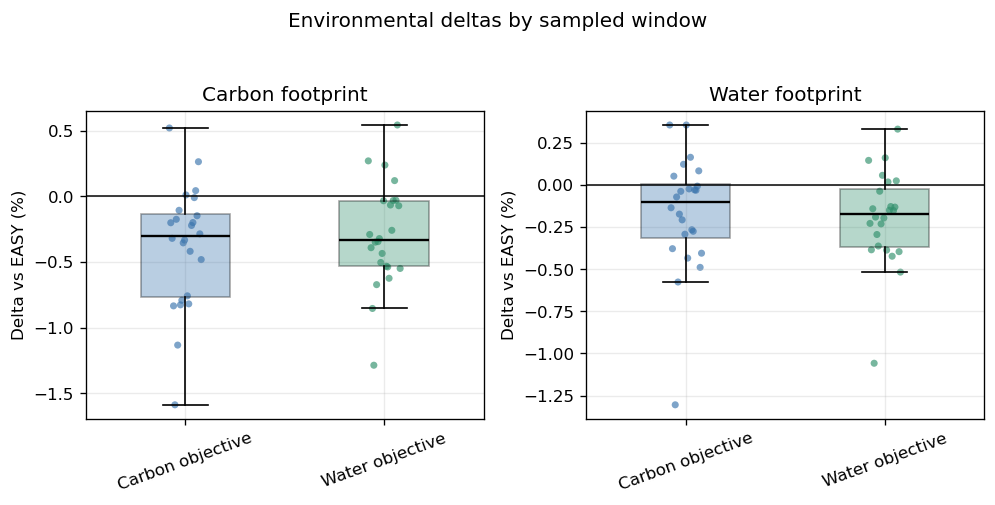

In [24]:
environmental_metrics = [
    "total_carbon_footprint_delta_pct",
    "total_water_footprint_delta_pct",
]
environmental_titles = ["Carbon footprint", "Water footprint"]
environmental_ylabels = ["Delta vs EASY (%)"] * len(environmental_metrics)

plot_delta_boxes(
    easy_comparisons,
    environmental_metrics,
    environmental_titles,
    environmental_ylabels,
    "Environmental deltas by sampled window",
);

This is the basic question: does greenfilling actually move the footprint it targets? Because the comparison is paired by window, a change in a high-carbon week and one in a low-carbon week each count within their own window. The spread looks small here, probably because of the stress workload.

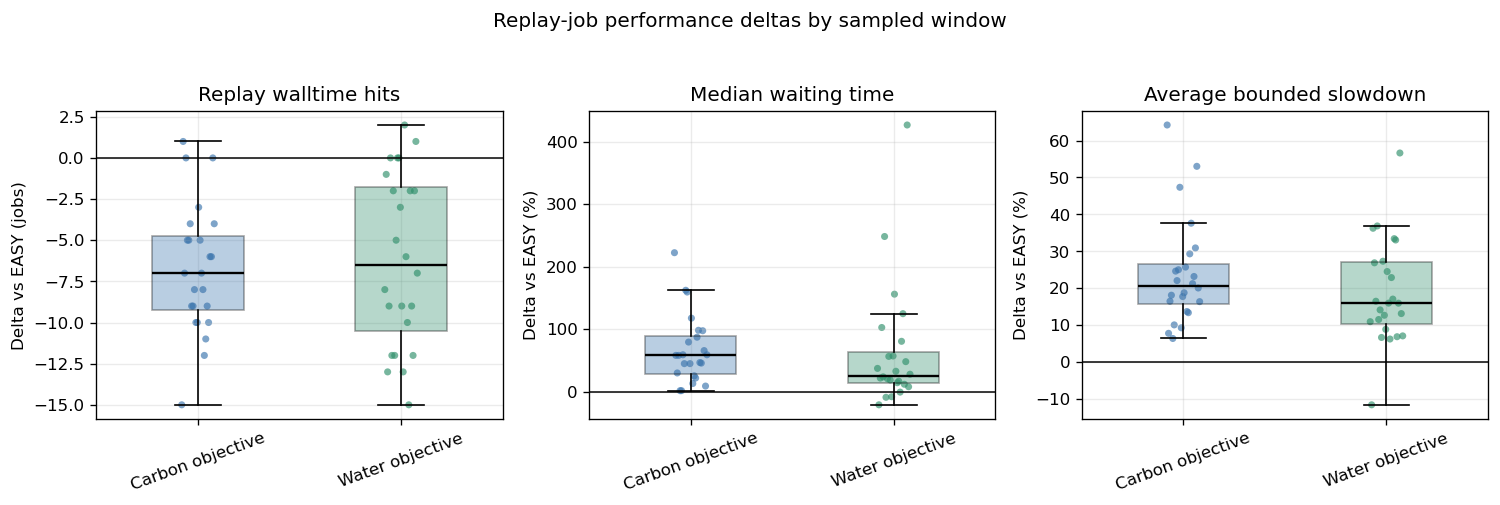

In [10]:
performance_metrics = [
    "replay_walltime_reached_delta",
    "replay_median_waiting_time_delta_pct",
    "replay_mean_bounded_slowdown_delta_pct",
]
performance_titles = [
    "Replay walltime hits",
    "Median waiting time",
    "Average bounded slowdown",
]
performance_ylabels = ["Delta vs EASY (jobs)"] + ["Delta vs EASY (%)"] * 2

plot_delta_boxes(
    easy_comparisons,
    performance_metrics,
    performance_titles,
    performance_ylabels,
    "Replay-job performance deltas by sampled window",
);

Here the point is what that footprint change costs on the replay jobs. An environmental gain matters less if it comes with more killed jobs or a jump in slowdown, so it is worth checking how the performance cost compares to the (small) footprint movement.

## Environmental saving versus performance penalty

The boxes above show each axis on its own. The next two scatters try to show the trade-off directly: one point per window, environmental saving on x, replay slowdown penalty on y. Roughly, lower-right is the nice region (less footprint, no extra slowdown), upper-right is a real trade-off, and left of zero means the footprint got worse in that window.

In [11]:
from matplotlib.lines import Line2D


season_order = ["winter", "spring", "summer", "autumn"]
season_colors = {
    "winter": "#4c78a8",
    "spring": "#54a24b",
    "summer": "#f2a541",
    "autumn": "#b279a2",
}
objective_markers = {
    "greenfilling_carbon": "o",
    "greenfilling_water": "^",
}


def plot_tradeoff_scatter(data, environmental_delta_column, x_label, title):
    plot_data = data.copy()
    plot_data["environmental_saving_pct"] = -plot_data[environmental_delta_column]
    plot_data["bounded_slowdown_penalty_pct"] = plot_data[
        "replay_mean_bounded_slowdown_delta_pct"
    ]

    zones = sorted(plot_data["zone"].unique())
    fig, axes = plt.subplots(1, len(zones), figsize=(4.4 * len(zones), 4.2), sharex=True, sharey=True)
    if len(zones) == 1:
        axes = [axes]

    x_values = plot_data["environmental_saving_pct"]
    y_values = plot_data["bounded_slowdown_penalty_pct"]
    x_padding = max((x_values.max() - x_values.min()) * 0.12, 0.25)
    y_padding = max((y_values.max() - y_values.min()) * 0.12, 1.0)

    for ax, zone in zip(axes, zones):
        zone_data = plot_data[plot_data["zone"].eq(zone)]
        for variant in variant_order:
            variant_data = zone_data[zone_data["greenfilling_variant"].eq(variant)]
            for season in season_order:
                points = variant_data[variant_data["season"].eq(season)]
                ax.scatter(
                    points["environmental_saving_pct"],
                    points["bounded_slowdown_penalty_pct"],
                    marker=objective_markers[variant],
                    s=58,
                    color=season_colors[season],
                    edgecolor="black",
                    linewidth=0.55,
                    alpha=0.85,
                )

        ax.axvline(0, color="black", linewidth=0.9)
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_title(zone)
        ax.set_xlabel(x_label)
        ax.set_xlim(x_values.min() - x_padding, x_values.max() + x_padding)
        ax.set_ylim(min(0, y_values.min() - y_padding), y_values.max() + y_padding)

    axes[0].set_ylabel("Replay average bounded slowdown penalty (%) vs EASY")

    season_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=season_colors[season], label=season.title(), markersize=7)
        for season in season_order
    ]
    objective_handles = [
        Line2D(
            [0],
            [0],
            marker=objective_markers[variant],
            linestyle="",
            color="black",
            label=variant_labels[variant],
            markersize=7,
        )
        for variant in variant_order
    ]

    fig.legend(handles=season_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08), frameon=False)
    fig.legend(handles=objective_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08), frameon=False)
    fig.suptitle(title, y=1.18)
    fig.tight_layout()
    return fig, axes

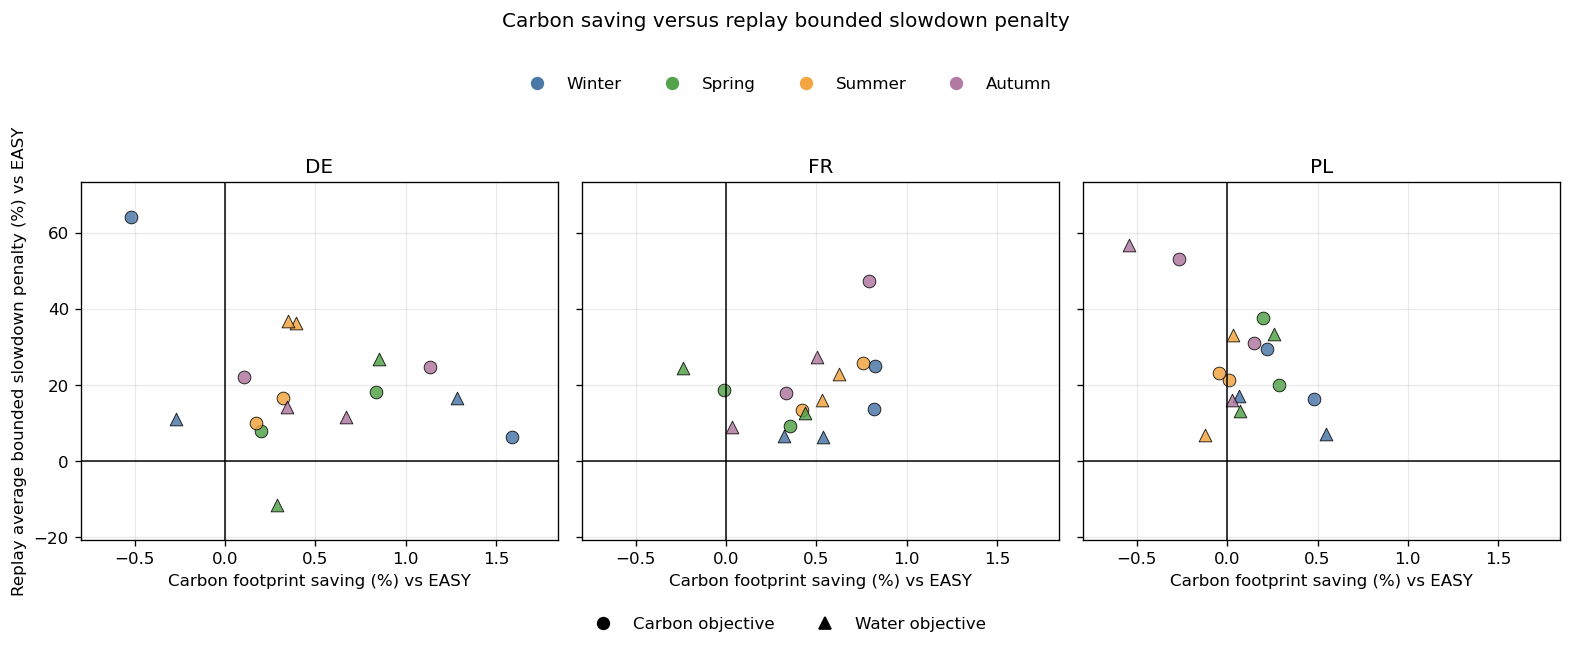

In [12]:
plot_tradeoff_scatter(
    easy_comparisons,
    "total_carbon_footprint_delta_pct",
    "Carbon footprint saving (%) vs EASY",
    "Carbon saving versus replay bounded slowdown penalty",
);

Carbon saving on the x-axis. I keep the water-objective points in too, since a scheduler tuned for one signal might still move the other.

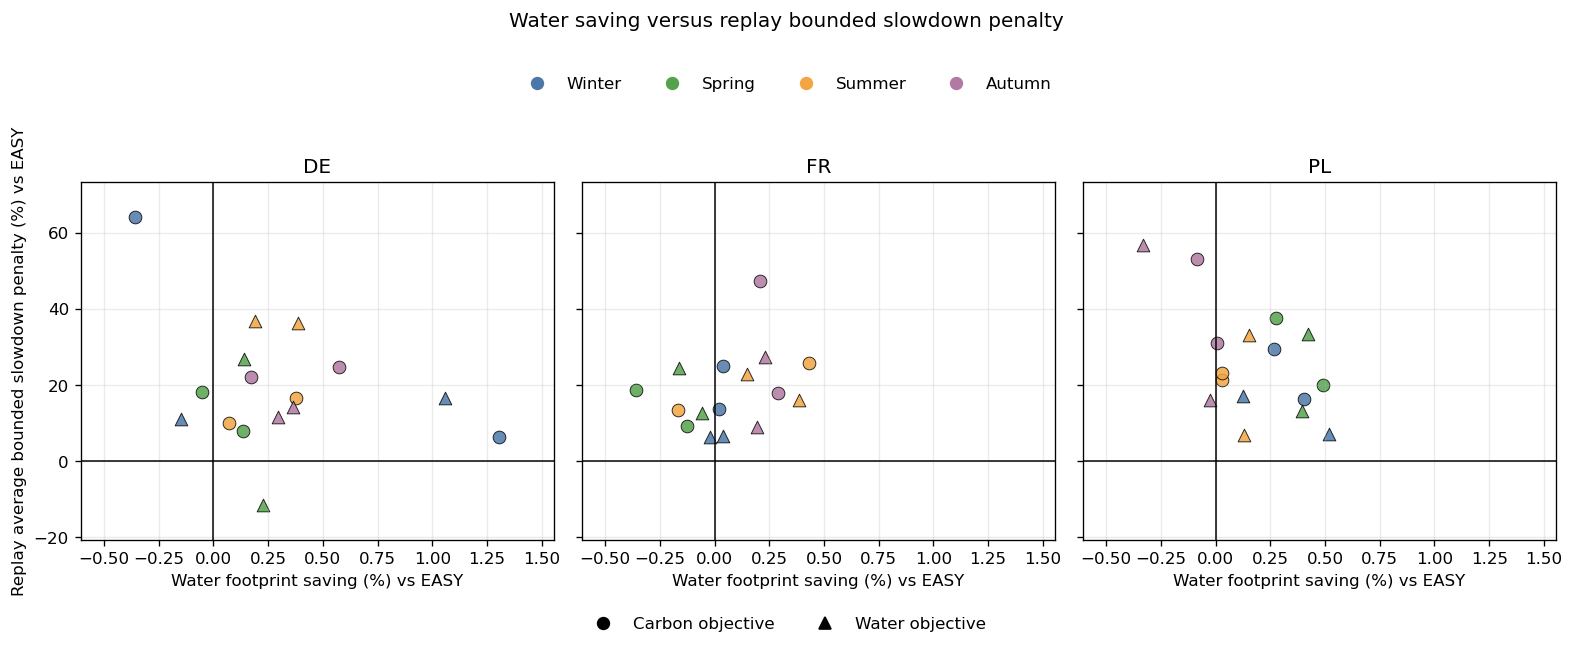

In [13]:
plot_tradeoff_scatter(
    easy_comparisons,
    "total_water_footprint_delta_pct",
    "Water footprint saving (%) vs EASY",
    "Water saving versus replay bounded slowdown penalty",
);

Same view for water. Putting it beside the carbon figure gives a rough sense of whether optimizing one signal helps or fights the other.

## Benefit-cost view: walltime hits

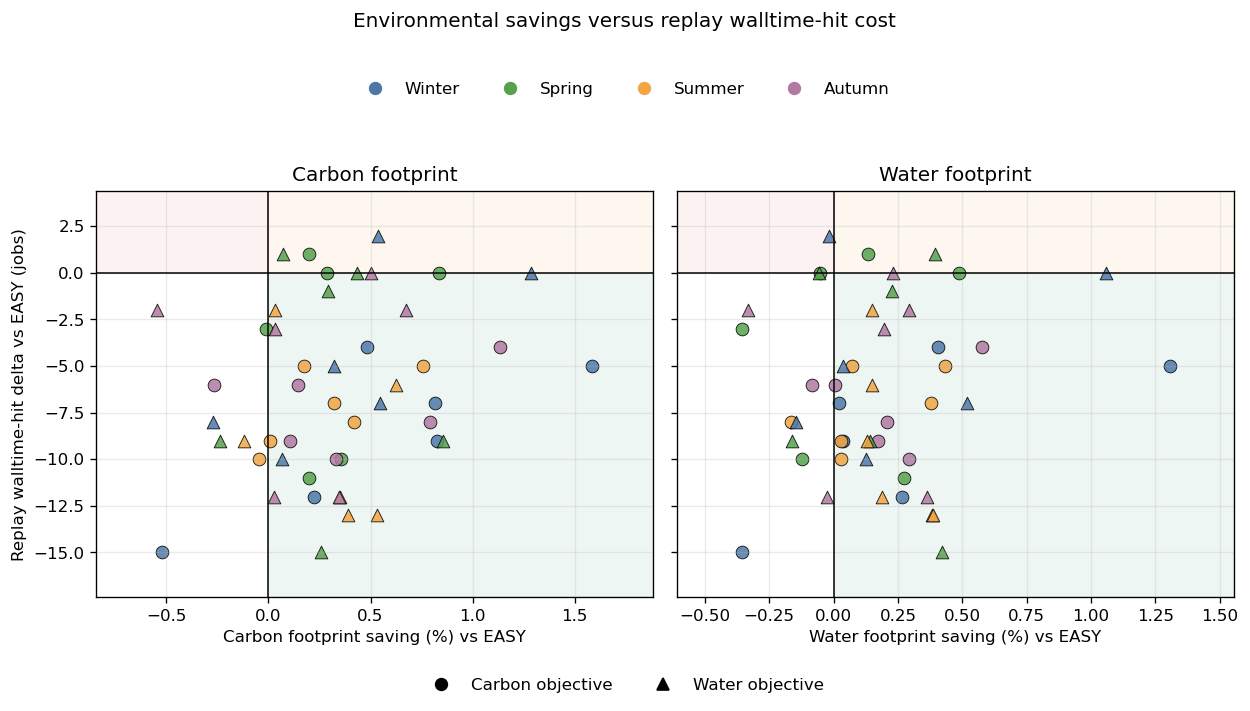

In [14]:
def plot_benefit_cost_quadrants(data):
    plot_specs = [
        ("total_carbon_footprint_delta_pct", "Carbon footprint saving (%) vs EASY", "Carbon footprint"),
        ("total_water_footprint_delta_pct", "Water footprint saving (%) vs EASY", "Water footprint"),
    ]

    fig, axes = plt.subplots(1, len(plot_specs), figsize=(10.5, 4.6), sharey=True)
    plot_data = data.copy()
    y_values = plot_data["replay_walltime_reached_delta"]
    y_padding = max((y_values.max() - y_values.min()) * 0.14, 1.0)
    y_lower = min(0, y_values.min() - y_padding)
    y_upper = max(0, y_values.max() + y_padding)

    for ax, (delta_column, x_label, title) in zip(axes, plot_specs):
        plot_data["environmental_saving_pct"] = -plot_data[delta_column]
        x_values = plot_data["environmental_saving_pct"]
        x_padding = max((x_values.max() - x_values.min()) * 0.14, 0.25)
        x_lower = x_values.min() - x_padding
        x_upper = x_values.max() + x_padding

        ax.fill_between([0, x_upper], y_lower, 0, color="#2f8f6b", alpha=0.08)
        ax.fill_between([0, x_upper], 0, y_upper, color="#f2a541", alpha=0.08)
        ax.fill_between([x_lower, 0], 0, y_upper, color="#d95f5f", alpha=0.08)

        for variant in variant_order:
            variant_data = plot_data[plot_data["greenfilling_variant"].eq(variant)]
            for season in season_order:
                points = variant_data[variant_data["season"].eq(season)]
                ax.scatter(
                    points["environmental_saving_pct"],
                    points["replay_walltime_reached_delta"],
                    marker=objective_markers[variant],
                    s=58,
                    color=season_colors[season],
                    edgecolor="black",
                    linewidth=0.55,
                    alpha=0.85,
                )

        ax.axvline(0, color="black", linewidth=0.9)
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_xlim(x_lower, x_upper)
        ax.set_ylim(y_lower, y_upper)

    axes[0].set_ylabel("Replay walltime-hit delta vs EASY (jobs)")

    season_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=season_colors[season], label=season.title(), markersize=7)
        for season in season_order
    ]
    objective_handles = [
        Line2D(
            [0],
            [0],
            marker=objective_markers[variant],
            linestyle="",
            color="black",
            label=variant_labels[variant],
            markersize=7,
        )
        for variant in variant_order
    ]

    fig.legend(handles=season_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08), frameon=False)
    fig.legend(handles=objective_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08), frameon=False)
    fig.suptitle("Environmental savings versus replay walltime-hit cost", y=1.18)
    fig.tight_layout()
    return fig, axes


plot_benefit_cost_quadrants(easy_comparisons);

This swaps the soft slowdown penalty for a harder one: the change in replay jobs that hit walltime. Lower-right is best (saving with no extra walltime hits), upper-right is the explicit trade-off, and upper-left would be the bad corner, worse footprint and more jobs killed.

## Does swing line up with the savings?

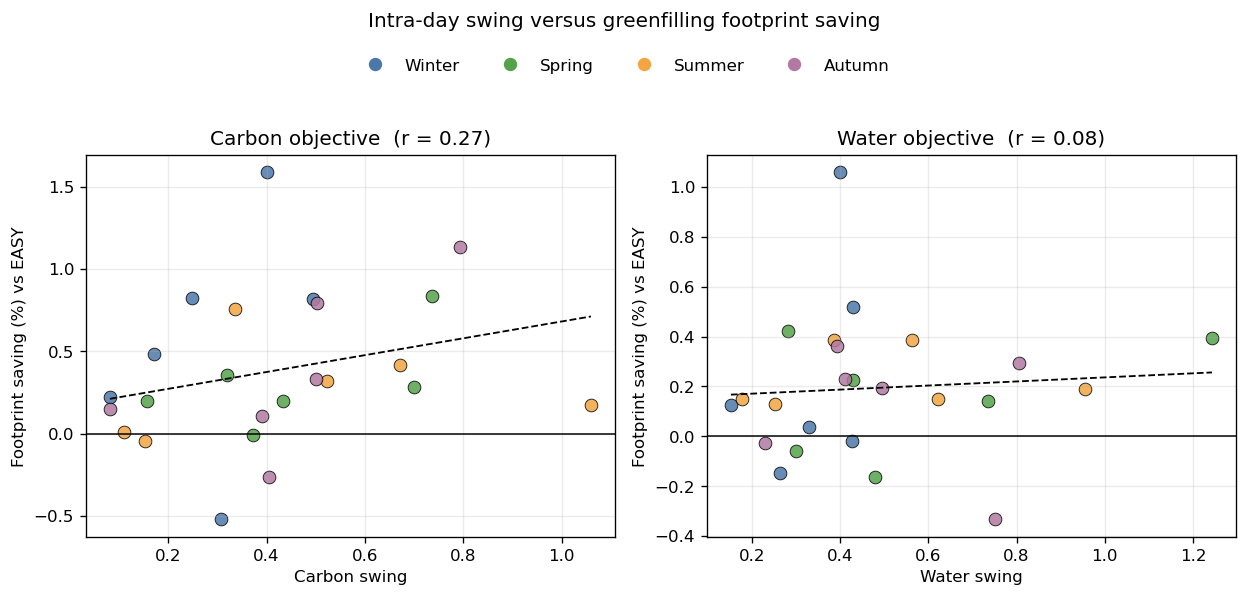

In [15]:
def plot_swing_relationship(data):
    specs = [
        ("greenfilling_carbon", "swing_carbon", "total_carbon_footprint_delta_pct", "Carbon objective", "Carbon swing"),
        ("greenfilling_water", "swing_water", "total_water_footprint_delta_pct", "Water objective", "Water swing"),
    ]

    fig, axes = plt.subplots(1, len(specs), figsize=(10.5, 4.4))
    for ax, (variant, swing_column, delta_column, title, x_label) in zip(axes, specs):
        subset = data[data["greenfilling_variant"].eq(variant)]
        swing = subset[swing_column].to_numpy()
        saving = -subset[delta_column].to_numpy()  # positive = footprint reduction vs EASY

        for season in season_order:
            points = subset[subset["season"].eq(season)]
            ax.scatter(
                points[swing_column],
                -points[delta_column],
                color=season_colors[season],
                edgecolor="black",
                linewidth=0.55,
                s=58,
                alpha=0.85,
            )

        if len(swing) > 1:
            slope, intercept = np.polyfit(swing, saving, 1)
            grid = np.linspace(swing.min(), swing.max(), 50)
            ax.plot(grid, slope * grid + intercept, color="black", linestyle="--", linewidth=1.1)
            r = np.corrcoef(swing, saving)[0, 1]
            ax.set_title(f"{title}  (r = {r:.2f})")
        else:
            ax.set_title(title)

        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Footprint saving (%) vs EASY")

    season_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=season_colors[season], label=season.title(), markersize=7)
        for season in season_order
    ]
    fig.legend(handles=season_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06), frameon=False)
    fig.suptitle("Intra-day swing versus greenfilling footprint saving", y=1.12)
    fig.tight_layout()
    return fig, axes


plot_swing_relationship(easy_comparisons);

`swing` is the mean daily peak-to-trough range of a signal over the window mean, so it is a rough proxy for how much daily variation the signal has. The loose idea is that more variation might give the scheduler more to work with, so savings could grow with swing. Each panel pairs a signal's swing with greenfilling's saving for the matching objective; the dashed line is a least-squares fit and `r` the correlation. With 24 windows and sub-percent effects this is suggestive at best, and I would not lean on the exact value.

## Takeaway

Greenfilling moves the footprint very little (median around -0.3% vs EASY, and the wrong way in some windows), while the replay jobs see somewhat longer waiting and higher slowdown. The carbon and water objectives look about the same. The effects are small.

A possible read is that a busy workload does not leave the scheduler much room, so reacting to the signal does not change the footprint much. A workload with more slack would be interesting to test.